# Face Verification with Siamese Networks on LFW

In [1]:
pip install mtcnn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, random, itertools, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                              f1_score, classification_report)
import pandas as pd

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import (EfficientNetB0,
                                            InceptionResNetV2)
from tensorflow.keras.preprocessing.image import img_to_array
from mtcnn import MTCNN

import kagglehub
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("All imports successful.")

path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", path)

2026-05-29 12:12:42.077174: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780056762.290648    1966 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780056762.350948    1966 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780056762.827726    1966 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780056762.827792    1966 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780056762.827795    1966 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
All imports successful.
Path to dataset files: /kaggle/input/datasets/jessicali9530/lfw-dataset


# Data Engineering: Parse, Filter

In [3]:
DATA_ROOT = None
for root, dirs, files in os.walk(path):
    if any(Path(root, d).is_dir() and 
           len(list(Path(root, d).glob('*.jpg'))) > 0
           for d in dirs):
        DATA_ROOT = Path(root)
        break

print(f"LFW root resolved to: {DATA_ROOT}")
assert DATA_ROOT is not None

# Parse folder structure
person_to_imgs = defaultdict(list)
for person_dir in sorted(DATA_ROOT.iterdir()):
    if person_dir.is_dir():
        imgs = sorted(person_dir.glob('*.jpg'))
        if imgs:
            person_to_imgs[person_dir.name] = [str(p) for p in imgs]

print(f"Total identities : {len(person_to_imgs)}")
print(f"Total images     : {sum(len(v) for v in person_to_imgs.values())}")

# Filter: keep only identities with enough images
MIN_IMAGES = 12
MAX_IMAGES = 30   # NEW: cap dominant identities to fix class imbalance

filtered = {
    p: imgs[:MAX_IMAGES]                          # cap first
    for p, imgs in person_to_imgs.items()
    if len(imgs) >= MIN_IMAGES                    # then filter
}

print(f"\nAfter filtering (>={MIN_IMAGES}) and capping (<={MAX_IMAGES}):")
print(f"  Identities : {len(filtered)}")
print(f"  Images     : {sum(len(v) for v in filtered.values())}")

LFW root resolved to: /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Total identities : 5749
Total images     : 13233

After filtering (>=12) and capping (<=30):
  Identities : 127
  Images     : 2648


Why filtering?


*   We keep only identities with ≥ MIN_IMAGES images.
*   Fewer images → only trivially-easy positive pairs (same lighting/pose), which causes the network to overfit on superficial cues.


*   MIN_IMAGES=10 gives enough intra-class variety while keeping ~1000+ identities.

# Visualize Identity Distribution

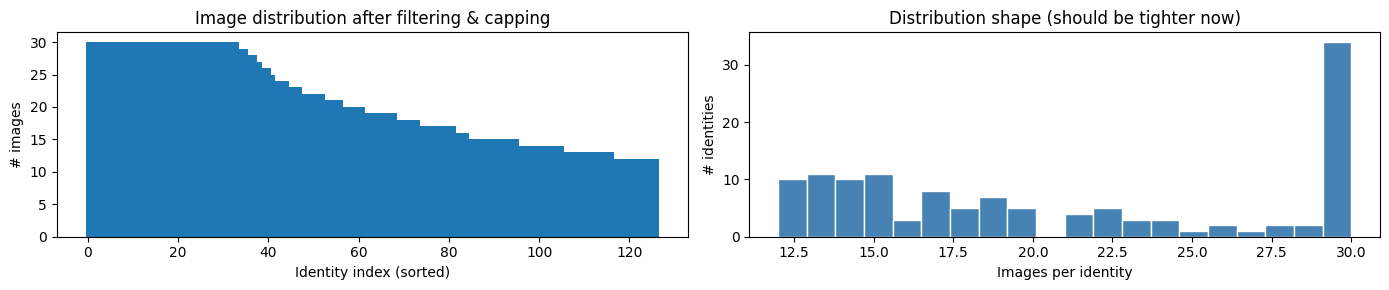

Min: 12  Max: 30  Mean: 20.9


In [4]:
counts = sorted([len(v) for v in filtered.values()], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].bar(range(len(counts)), counts, width=1.0)
axes[0].set_xlabel('Identity index (sorted)')
axes[0].set_ylabel('# images')
axes[0].set_title('Image distribution after filtering & capping')

axes[1].hist(counts, bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Images per identity')
axes[1].set_ylabel('# identities')
axes[1].set_title('Distribution shape (should be tighter now)')

plt.tight_layout()
plt.show()

print(f"Min: {min(counts)}  Max: {max(counts)}  Mean: {np.mean(counts):.1f}")

# MTCNN Face Loader


In [5]:
#pip https://python-lz4.readthedocs.io/
!pip install lz4


I0000 00:00:1780056808.474695    1966 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780056808.480871    1966 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


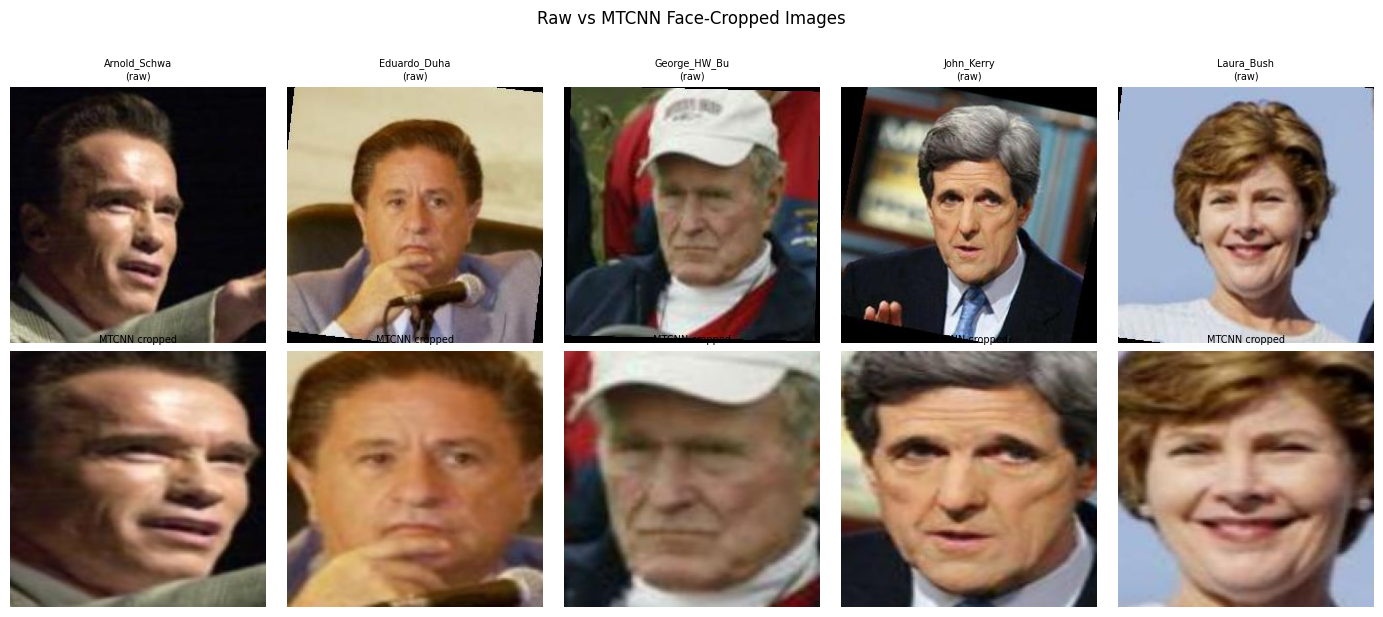

In [6]:
IMG_SIZE = (160, 160)   
detector = MTCNN()

def load_image(path: str, size=IMG_SIZE) -> np.ndarray:
    """
    Load image, detect and crop face region using MTCNN,
    resize to `size`, normalize to [0,1].
    Falls back to full image if no face is detected.
    """
    img = Image.open(path).convert('RGB')
    img_array = np.array(img)

    results = detector.detect_faces(img_array)
    if results:
        x, y, w, h = results[0]['box']
        # Add 15% margin around detected face
        margin_x = int(w * 0.15)
        margin_y = int(h * 0.15)
        x = max(0, x - margin_x)
        y = max(0, y - margin_y)
        w = min(img_array.shape[1] - x, w + 2 * margin_x)
        h = min(img_array.shape[0] - y, h + 2 * margin_y)
        img_array = img_array[y:y+h, x:x+w]

    img = Image.fromarray(img_array).resize(size, Image.BILINEAR)
    return img_to_array(img).astype('float32') / 255.0


# Sanity check — visualize raw vs cropped for 5 identities
persons = list(filtered.keys())
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_persons = random.sample(persons, 5)

for i, person in enumerate(sample_persons):
    # Raw image
    raw = Image.open(filtered[person][0]).convert('RGB')
    axes[0, i].imshow(raw)
    axes[0, i].set_title(f'{person[:12]}\n(raw)', fontsize=7)
    axes[0, i].axis('off')

    # MTCNN cropped
    cropped = load_image(filtered[person][0])
    axes[1, i].imshow(cropped)
    axes[1, i].set_title('MTCNN cropped', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Raw vs MTCNN Face-Cropped Images', y=1.02)
plt.tight_layout()
plt.show()

MTCNN (Multi-task Cascaded Convolutional Networks) detects and crops the face region automatically. It's the standard preprocessing step used in FaceNet and DeepFace papers themselves.

# Train & Validation Split


In [7]:
train_persons, val_persons = train_test_split(
    persons, test_size=0.2, random_state=SEED
)
print(f"Train identities : {len(train_persons)}")
print(f"Val   identities : {len(val_persons)}")

Train identities : 101
Val   identities : 26


The split took place at the identity level, not at the image level so that the validation set contains completely unseen people. Therefore, harder and more realistic evaluation scenario for face verification.

# Pair Gerenrator

In [8]:
def generate_pairs(person_dict: dict,
                   n_pairs_per_person: int = 15,
                   neg_ratio: float = 1.0) -> tuple:
    """
    Generates balanced same/different pairs.
    
    Key design choices:
    - Identity-level negative sampling: for each anchor identity,
      negatives are drawn from ALL other identities with equal
      probability — prevents any single identity from dominating
      negative pairs.
    - neg_ratio=1.0 keeps label balance at 50/50.
    """
    pairs_A, pairs_B, labels = [], [], []
    people = list(person_dict.keys())

    for person in people:
        imgs = person_dict[person]

        # Positive pairs
        pos_combos = list(itertools.combinations(imgs, 2))
        sampled_pos = random.sample(
            pos_combos, min(n_pairs_per_person, len(pos_combos))
        )
        for a, b in sampled_pos:
            pairs_A.append(load_image(a))
            pairs_B.append(load_image(b))
            labels.append(1)

        # Negative pairs — sample uniformly across all other identities
        n_neg = int(len(sampled_pos) * neg_ratio)
        other_people = [p for p in people if p != person]
        for _ in range(n_neg):
            neg_person = random.choice(other_people)
            neg_img    = random.choice(person_dict[neg_person])
            anchor_img = random.choice(imgs)
            pairs_A.append(load_image(anchor_img))
            pairs_B.append(load_image(neg_img))
            labels.append(0)

    # Shuffle
    combined = list(zip(pairs_A, pairs_B, labels))
    random.shuffle(combined)
    pairs_A, pairs_B, labels = zip(*combined)

    return (np.array(pairs_A, dtype='float32'),
            np.array(pairs_B, dtype='float32'),
            np.array(labels,  dtype='float32'))

print("Generating training pairs...")
train_A, train_B, train_labels = generate_pairs(
    {p: filtered[p] for p in train_persons},
    n_pairs_per_person=20
)
print("Generating validation pairs...")
val_A, val_B, val_labels = generate_pairs(
    {p: filtered[p] for p in val_persons},
    n_pairs_per_person=15
)

print(f"\nTrain pairs : {len(train_labels)}"
      f"  |  Pos: {int(train_labels.sum())}"
      f"  Neg: {int((1-train_labels).sum())}")
print(f"Val   pairs : {len(val_labels)}"
      f"  |  Pos: {int(val_labels.sum())}"
      f"  Neg: {int((1-val_labels).sum())}")

Generating training pairs...
Generating validation pairs...

Train pairs : 4040  |  Pos: 2020  Neg: 2020
Val   pairs : 780  |  Pos: 390  Neg: 390


# Triplet Generator with Hard Mining (FaceNet-style)

In [9]:
def generate_triplets(person_dict: dict,
                      n_triplets_per_person: int = 20) -> tuple:
    """
    Random triplet generation for initial warm-up training.
    Hard mining (Cell 16) takes over after warm-up.
    """
    anchors, positives, negatives = [], [], []
    people = list(person_dict.keys())

    for person in people:
        imgs = person_dict[person]
        if len(imgs) < 2:
            continue
        neg_pool = [p for p in people if p != person]

        for _ in range(n_triplets_per_person):
            a_path, p_path = random.sample(imgs, 2)
            neg_person      = random.choice(neg_pool)
            n_path          = random.choice(person_dict[neg_person])

            anchors.append(load_image(a_path))
            positives.append(load_image(p_path))
            negatives.append(load_image(n_path))

    data = list(zip(anchors, positives, negatives))
    random.shuffle(data)
    anchors, positives, negatives = zip(*data)

    return (np.array(anchors,   dtype='float32'),
            np.array(positives, dtype='float32'),
            np.array(negatives, dtype='float32'))


def mine_hard_triplets(backbone, person_dict: dict,
                       n_per_person: int = 10,
                       batch_size: int = 64) -> tuple:
    """
    FaceNet-style semi-hard triplet mining.
    
    For each anchor:
    - Hard positive : same identity, MAXIMUM embedding distance
    - Hard negative : different identity, MINIMUM embedding distance
                      that still violates the margin (semi-hard)
    
    Why semi-hard and not fully hard negatives?
    Fully hard negatives (closest possible different-person embedding)
    often cause training collapse early on — the model gets stuck trying
    to separate embeddings that are genuinely ambiguous. Semi-hard
    negatives (d_neg > d_pos but d_neg < d_pos + margin) give the model
    meaningful gradient signal without causing collapse.
    """
    people = list(person_dict.keys())

    # Step 1: compute all embeddings in one pass
    all_imgs, all_labels_idx = [], []
    for idx, person in enumerate(people):
        for img_path in person_dict[person]:
            all_imgs.append(load_image(img_path))
            all_labels_idx.append(idx)

    all_imgs   = np.array(all_imgs, dtype='float32')
    all_labels_idx = np.array(all_labels_idx)

    # Batch-predict embeddings
    embeddings = backbone.predict(all_imgs, batch_size=batch_size,
                                  verbose=0)

    # Step 2: mine triplets
    anchors, positives, negatives = [], [], []
    margin = 0.4

    for idx, person in enumerate(people):
        person_mask = all_labels_idx == idx
        other_mask  = all_labels_idx != idx

        person_embs = embeddings[person_mask]
        person_imgs = all_imgs[person_mask]
        other_embs  = embeddings[other_mask]
        other_imgs  = all_imgs[other_mask]

        if len(person_embs) < 2:
            continue

        # Sample n_per_person anchors from this identity
        anchor_indices = random.sample(range(len(person_embs)),
                                       min(n_per_person,
                                           len(person_embs)))

        for a_idx in anchor_indices:
            anchor_emb = person_embs[a_idx]

            # Hard positive: furthest same-identity embedding
            pos_dists = np.linalg.norm(
                person_embs - anchor_emb, axis=1
            )
            pos_dists[a_idx] = -1  # exclude self
            hard_pos_idx = np.argmax(pos_dists)

            # Semi-hard negative: different identity,
            # d_neg in (d_pos, d_pos + margin)
            d_pos = pos_dists[hard_pos_idx]
            neg_dists = np.linalg.norm(
                other_embs - anchor_emb, axis=1
            )
            semi_hard_mask = (neg_dists > d_pos) & \
                             (neg_dists < d_pos + margin)

            if semi_hard_mask.sum() > 0:
                # Pick closest semi-hard negative
                neg_candidates = np.where(semi_hard_mask)[0]
                hard_neg_idx = neg_candidates[
                    np.argmin(neg_dists[neg_candidates])
                ]
            else:
                # Fall back to closest negative if no semi-hard found
                hard_neg_idx = np.argmin(neg_dists)

            anchors.append(person_imgs[a_idx])
            positives.append(person_imgs[hard_pos_idx])
            negatives.append(other_imgs[hard_neg_idx])

    data = list(zip(anchors, positives, negatives))
    random.shuffle(data)
    anchors, positives, negatives = zip(*data)

    print(f"Mined {len(anchors)} hard triplets from "
          f"{len(people)} identities")

    return (np.array(anchors,   dtype='float32'),
            np.array(positives, dtype='float32'),
            np.array(negatives, dtype='float32'))


# Generate initial random triplets for warm-up
print("Generating training triplets (random, for warm-up)...")
tr_A, tr_P, tr_N = generate_triplets(
    {p: filtered[p] for p in train_persons},
    n_triplets_per_person=25
)
print("Generating validation triplets...")
va_A, va_P, va_N = generate_triplets(
    {p: filtered[p] for p in val_persons},
    n_triplets_per_person=15
)

print(f"\nTrain triplets : {len(tr_A)}")
print(f"Val   triplets : {len(va_A)}")

Generating training triplets (random, for warm-up)...
Generating validation triplets...

Train triplets : 2525
Val   triplets : 390


# Loss Functions


In [10]:
# ── DeepFace-style: Binary Cross-Entropy ─────────────────────────────────────
# Standard BCE is built into Keras — no manual implementation needed.
# We use it with a sigmoid output on the distance score.
# This treats verification as binary classification: same(1) or different(0).

def deepface_accuracy(y_true, y_pred):
    """Accuracy at fixed 0.5 decision threshold on sigmoid similarity score."""
    return K.mean(K.equal(
        tf.cast(tf.reshape(y_true, tf.shape(y_pred)), 'float32'),
        K.cast(y_pred > 0.5, 'float32')
    ))


# ── FaceNet-style: Triplet Loss ───────────────────────────────────────────────
def triplet_loss_fn(margin=0.4):
    """
    Soft-margin triplet loss.
    margin=0.4 is the value used in the original FaceNet paper.
    """
    def loss(y_true, y_pred):
        anchor   = y_pred[:, 0, :]
        positive = y_pred[:, 1, :]
        negative = y_pred[:, 2, :]
        d_pos = K.sum(K.square(anchor - positive), axis=1)
        d_neg = K.sum(K.square(anchor - negative), axis=1)
        return K.mean(K.maximum(d_pos - d_neg + margin, 0.0))
    return loss

def triplet_accuracy(y_true, y_pred):
    """Fraction of triplets where d(anchor,positive) < d(anchor,negative)."""
    anchor   = y_pred[:, 0, :]
    positive = y_pred[:, 1, :]
    negative = y_pred[:, 2, :]
    d_pos = K.sum(K.square(anchor - positive), axis=1)
    d_neg = K.sum(K.square(anchor - negative), axis=1)
    return K.mean(K.cast(d_pos < d_neg, 'float32'))


# ── Euclidean distance layer (shared by both models) ─────────────────────────
def euclidean_distance(vecs):
    x, y = vecs
    return K.sqrt(K.maximum(
        K.sum(K.square(x - y), axis=1, keepdims=True),
        K.epsilon()
    ))

print("Loss functions defined.")

Loss functions defined.


# Architecture 1: Custom CNN Backbone

In [11]:
def build_custom_backbone(input_shape=(160, 160, 3),
                           embedding_dim=128):
    """
    Custom CNN backbone designed from scratch for face similarity.

    Architecture decisions:
    - 4 conv blocks with increasing filters (32→64→128→256):
      progressively extracts low-level (edges, textures) to
      high-level (facial structure) features.
    - Two conv layers per block before pooling: deeper feature
      extraction per spatial scale without aggressive downsampling.
    - BatchNormalization after every conv: stabilizes training,
      reduces internal covariate shift, allows higher LR.
    - MaxPooling(2) after each block: halves spatial dimensions,
      builds spatial invariance.
    - Dropout(0.25) between blocks: prevents co-adaptation of
      feature detectors, reduces overfitting on small identity sets.
    - GlobalAveragePooling instead of Flatten: reduces parameters
      dramatically and improves spatial generalization.
    - Dense(256) → Dense(128): bottleneck forces compact
      face representation.
    - L2 normalization on output: embeddings on unit hypersphere,
      consistent distance scale across all pairs/triplets.
    - embedding_dim=128: matches FaceNet and DeepFace backbones
      for fair comparison in evaluation.
    """
    inp = layers.Input(shape=input_shape)

    # Block 1 — low-level features (edges, textures)
    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2 — mid-level features (shapes, contours)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3 — facial structure features
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 4 — high-level identity features
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Embedding head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim)(x)
    x = layers.Lambda(
            lambda t: tf.math.l2_normalize(t, axis=1),
            name='l2_norm'
        )(x)

    return models.Model(inp, x, name='custom_cnn_backbone')


backbone_cnn = build_custom_backbone()
backbone_cnn.summary()

Model: "custom_cnn_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,275,808 (4.87 MB)

 Trainable params: 1,273,376 (4.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

# Custom CNN Siamese Model (Pairs + BCE)

In [12]:
def build_siamese_pairs(backbone, name='siamese_pairs'):
    """
    Siamese network for pair-based verification (DeepFace-style).
    Shared backbone processes both inputs.
    Euclidean distance fed into sigmoid head → BCE loss.
    Reused for both Custom CNN and ResNet50V2 backbones.
    """
    input_a = layers.Input(shape=(160, 160, 3), name='input_a')
    input_b = layers.Input(shape=(160, 160, 3), name='input_b')

    emb_a = backbone(input_a)
    emb_b = backbone(input_b)

    distance = layers.Lambda(
        euclidean_distance,
        name='euclidean_distance'
    )([emb_a, emb_b])

    similarity = layers.Dense(
        1, activation='sigmoid', name='similarity'
    )(distance)

    return models.Model(
        inputs=[input_a, input_b],
        outputs=similarity,
        name=name
    )


def build_siamese_triplets(backbone, name='siamese_triplets'):
    """
    Siamese network for triplet-based verification (FaceNet-style).
    Shared backbone processes anchor, positive, negative.
    Stacked embeddings output → triplet loss.
    Reused for both Custom CNN and InceptionResNetV2 backbones.
    """
    input_a = layers.Input(shape=(160, 160, 3), name='anchor')
    input_p = layers.Input(shape=(160, 160, 3), name='positive')
    input_n = layers.Input(shape=(160, 160, 3), name='negative')

    emb_a = backbone(input_a)
    emb_p = backbone(input_p)
    emb_n = backbone(input_n)

    stacked = layers.Lambda(
        lambda x: tf.stack(x, axis=1),
        name='stack_embeddings'
    )([emb_a, emb_p, emb_n])

    return models.Model(
        inputs=[input_a, input_p, input_n],
        outputs=stacked,
        name=name
    )


# Build both Siamese models for Custom CNN
siamese_cnn_pairs    = build_siamese_pairs(
    backbone_cnn, name='siamese_cnn_pairs'
)
siamese_cnn_triplets = build_siamese_triplets(
    backbone_cnn, name='siamese_cnn_triplets'
)

print("Custom CNN Siamese models built.")
siamese_cnn_pairs.summary()

Custom CNN Siamese models built.


Model: "siamese_cnn_pairs"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_a             │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_b             │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_cnn_backbone │ (None, 128)       │  1,275,808 │ input_a[0][0],    │
│ (Functional)        │                   │            │ input_b[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ euclidean_distance  │ (None, 1)         │          0 │ custom_cnn_backb… │
│ (Lambda)            │                   │            │ custom_cnn_backb… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similarity (Dense)  │ (None, 1)         │          2 │ euclidean_distan… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,275,810 (4.87 MB)

 Trainable params: 1,273,378 (4.86 MB)

 Non-trainable params: 2,432 (9.50 KB)

# Callbacks

In [13]:
def make_callbacks(run_name: str):
    """
    - EarlyStopping    : stops if val_loss stagnates for 5 epochs,
                         restores best weights.
    - ReduceLROnPlateau: halves LR after 3 stagnant epochs.
    - ModelCheckpoint  : saves best weights per run.
    """
    return [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{run_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]

BATCH_SIZE = 32
print("Callbacks defined.")

Callbacks defined.


 # Train Custom CNN Pairs: Warm-up

In [14]:
"""
Custom CNN has no pretrained weights so the two-phase strategy
works differently here compared to ResNet/InceptionResNet:

Phase 1 — Full training from scratch (this cell):
    All layers train from random initialization.
    Higher LR (1e-3) with Adam is appropriate for training
    from scratch — the network needs larger steps early on.

Phase 2 — Refinement (next cell):
    LR reduced to 1e-4 to fine-tune the converged network.
    This is analogous to the fine-tuning phase in pretrained
    models but applied to a from-scratch CNN.
"""

siamese_cnn_pairs.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[deepface_accuracy]
)

print("Training Custom CNN + Pairs (Phase 1: full training)...")
hist_cnn_pairs_p1 = siamese_cnn_pairs.fit(
    [train_A, train_B], train_labels,
    batch_size=BATCH_SIZE,
    epochs=30,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('cnn_pairs_phase1'),
    verbose=1
)
print("Phase 1 complete.")

Training Custom CNN + Pairs (Phase 1: full training)...
Epoch 1/30


I0000 00:00:1780059945.057336    2016 service.cc:152] XLA service 0x78c1700a6450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780059945.057381    2016 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780059945.057384    2016 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780059946.738369    2016 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-29 13:05:52.892953: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:05:53.050536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:05:55.131929: E external/local_xl

126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - deepface_accuracy: 0.4882 - loss: 0.8736

2026-05-29 13:06:34.603064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:06:34.751226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:06:35.476697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:06:35.763663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


127/127 ━━━━━━━━━━━━━━━━━━━━ 78s 368ms/step - deepface_accuracy: 0.4978 - loss: 0.8300 - val_deepface_accuracy: 0.5263 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 2/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - deepface_accuracy: 0.5005 - loss: 0.7112 - val_deepface_accuracy: 0.5925 - val_loss: 0.6748 - learning_rate: 0.0010
Epoch 3/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 183ms/step - deepface_accuracy: 0.5381 - loss: 0.6703 - val_deepface_accuracy: 0.6129 - val_loss: 0.6631 - learning_rate: 0.0010
Epoch 4/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 179ms/step - deepface_accuracy: 0.5994 - loss: 0.6601 - val_deepface_accuracy: 0.6050 - val_loss: 0.6583 - learning_rate: 0.0010
Epoch 5/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - deepface_accuracy: 0.6188 - loss: 0.6525 - val_deepface_accuracy: 0.6012 - val_loss: 0.6588 - learning_rate: 0.0010
Epoch 6/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - deepface_accuracy: 0.6358 - loss: 0.6472 - val_deepface_accuracy: 0.5958 - val_loss: 0.66

# Train Custom CNN Pairs: Refinement

In [15]:
siamese_cnn_pairs.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[deepface_accuracy]
)

print("Training Custom CNN + Pairs (Phase 2: refinement)...")
hist_cnn_pairs_p2 = siamese_cnn_pairs.fit(
    [train_A, train_B], train_labels,
    batch_size=16,
    epochs=20,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('cnn_pairs_phase2'),
    verbose=1
)
print("Phase 2 complete.")

Training Custom CNN + Pairs (Phase 2: refinement)...
Epoch 1/20


2026-05-29 13:18:11.447067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:18:11.597115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:18:12.688508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:18:12.972076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:18:13.232271: E external/local_xla/xla/service

253/253 ━━━━━━━━━━━━━━━━━━━━ 69s 168ms/step - deepface_accuracy: 0.7320 - loss: 0.5801 - val_deepface_accuracy: 0.6344 - val_loss: 0.6354 - learning_rate: 1.0000e-04
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - deepface_accuracy: 0.7278 - loss: 0.5785 - val_deepface_accuracy: 0.6386 - val_loss: 0.6318 - learning_rate: 1.0000e-04
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - deepface_accuracy: 0.7292 - loss: 0.5751 - val_deepface_accuracy: 0.6322 - val_loss: 0.6397 - learning_rate: 1.0000e-04
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - deepface_accuracy: 0.7344 - loss: 0.5723 - val_deepface_accuracy: 0.6433 - val_loss: 0.6320 - learning_rate: 1.0000e-04
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - deepface_accuracy: 0.7295 - loss: 0.5710
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
253/253 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - deepface_accuracy: 0.7330 - loss: 0.5708 - val_deepface_accuracy: 0.6407 - val_loss: 0.63

# Train Custom CNN Triplets: Warm-up

In [16]:
dummy_train = np.zeros((len(tr_A), 1))
dummy_val   = np.zeros((len(va_A), 1))

siamese_cnn_triplets.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

print("Training Custom CNN + Triplets (Phase 1: random triplets)...")
hist_cnn_triplets_p1 = siamese_cnn_triplets.fit(
    [tr_A, tr_P, tr_N], dummy_train,
    batch_size=BATCH_SIZE,
    epochs=30,
    validation_data=([va_A, va_P, va_N], dummy_val),
    callbacks=make_callbacks('cnn_triplets_phase1'),
    verbose=1
)
print("Phase 1 complete.")

Training Custom CNN + Triplets (Phase 1: random triplets)...
Epoch 1/30
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.3787 - triplet_accuracy: 0.7212

2026-05-29 13:22:30.114261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:22:30.268336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:22:31.919958: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 13:22:32.208708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


79/79 ━━━━━━━━━━━━━━━━━━━━ 79s 669ms/step - loss: 0.3458 - triplet_accuracy: 0.7085 - val_loss: 0.3030 - val_triplet_accuracy: 0.7035 - learning_rate: 0.0010
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - loss: 0.2499 - triplet_accuracy: 0.7429 - val_loss: 0.3170 - val_triplet_accuracy: 0.7043 - learning_rate: 0.0010
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 270ms/step - loss: 0.2446 - triplet_accuracy: 0.7477 - val_loss: 0.2910 - val_triplet_accuracy: 0.6891 - learning_rate: 0.0010
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - loss: 0.2390 - triplet_accuracy: 0.7540 - val_loss: 0.3014 - val_triplet_accuracy: 0.7083 - learning_rate: 0.0010
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 264ms/step - loss: 0.2250 - triplet_accuracy: 0.7801 - val_loss: 0.3874 - val_triplet_accuracy: 0.6771 - learning_rate: 0.0010
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 0.2294 - triplet_accuracy: 0.7664
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00050000002374872

# Train Custom CNN Triplets: Hard Mining

In [ ]:
print("Mining hard triplets using Custom CNN embeddings...")
tr_A_hard_cnn, tr_P_hard_cnn, tr_N_hard_cnn = mine_hard_triplets(
    backbone_cnn,
    {p: filtered[p] for p in train_persons},
    n_per_person=10
)
va_A_hard_cnn, va_P_hard_cnn, va_N_hard_cnn = mine_hard_triplets(
    backbone_cnn,
    {p: filtered[p] for p in val_persons},
    n_per_person=8
)

dummy_train_hard = np.zeros((len(tr_A_hard_cnn), 1))
dummy_val_hard   = np.zeros((len(va_A_hard_cnn), 1))

siamese_cnn_triplets.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

print("Training Custom CNN + Triplets (Phase 2: hard triplets)...")
hist_cnn_triplets_p2 = siamese_cnn_triplets.fit(
    [tr_A_hard_cnn, tr_P_hard_cnn, tr_N_hard_cnn], dummy_train_hard,
    batch_size=16,
    epochs=25,
    validation_data=(
        [va_A_hard_cnn, va_P_hard_cnn, va_N_hard_cnn],
        dummy_val_hard
    ),
    callbacks=make_callbacks('cnn_triplets_phase2'),
    verbose=1
)
print("Hard triplet phase complete.")

Mining hard triplets using Custom CNN embeddings...


# Architecture 2: DeepFace-style Backbone (ResNet50V2)

In [ ]:
from tensorflow.keras.applications import ResNet50V2

def build_deepface_backbone(input_shape=(160, 160, 3),
                             embedding_dim=128):
    """
    DeepFace-style backbone using ResNet50V2.

    Design choices:
    - ResNet50V2 pretrained on ImageNet as feature extractor.
    - Global Average Pooling instead of Flatten to reduce parameters
      and improve spatial generalization.
    - Dense(256) intermediate layer with ReLU adds task-specific
      capacity before the embedding.
    - BatchNormalization before embedding stabilizes training.
    - Dropout(0.3) prevents co-adaptation of embedding neurons.
    - L2 normalization on output: embeddings live on unit hypersphere,
      making cosine similarity equivalent to dot product and keeping
      distances consistent across batches.
    - embedding_dim=128: same as FaceNet, compact but expressive.
    """
    base = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'        # Global Average Pooling built-in
    )
    base.trainable = False   # Frozen for warm-up phase

    inp = layers.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(embedding_dim)(x)
    x   = layers.Lambda(
              lambda t: tf.math.l2_normalize(t, axis=1),
              name='l2_norm'
          )(x)

    return models.Model(inp, x, name='deepface_backbone')


backbone_df = build_deepface_backbone()
backbone_df.summary()

# DeepFace-style Siamese Model (Pairs + BCE)

In [ ]:
def build_siamese_deepface(backbone):
    """
    DeepFace-style Siamese network for pair verification.

    Architecture:
    - Two inputs share the same backbone (shared weights).
    - Euclidean distance computed between the two embeddings.
    - Distance passed through a Dense(1) + sigmoid to produce
      a similarity score in [0,1].
    - Trained with Binary Cross-Entropy:
        score → 1 means same person
        score → 0 means different person

    Why BCE instead of Contrastive Loss here?
    BCE treats verification as binary classification and provides
    cleaner gradient signal when combined with a learned similarity
    head. Contrastive loss operates directly on raw distances and
    requires careful margin tuning. DeepFace used this classification
    framing in its original formulation.
    """
    input_a = layers.Input(shape=(160, 160, 3), name='input_a')
    input_b = layers.Input(shape=(160, 160, 3), name='input_b')

    emb_a = backbone(input_a)
    emb_b = backbone(input_b)

    # Euclidean distance between embeddings
    distance = layers.Lambda(
        euclidean_distance,
        name='euclidean_distance'
    )([emb_a, emb_b])

    # Learned similarity head: maps distance → probability
    similarity = layers.Dense(1, activation='sigmoid',
                               name='similarity')(distance)

    return models.Model(
        inputs=[input_a, input_b],
        outputs=similarity,
        name='siamese_deepface'
    )


siamese_df = build_siamese_deepface(backbone_df)
siamese_df.summary()

# Training Callbacks

In [ ]:
def make_callbacks(run_name: str):
    """
    Shared callbacks for all training runs.

    - EarlyStopping: stops if val_loss does not improve for 5 epochs,
      restores best weights automatically.
    - ReduceLROnPlateau: halves LR after 3 epochs of no val_loss
      improvement — prevents overshooting flat loss regions.
    - ModelCheckpoint: saves best model to disk for later evaluation.
    """
    return [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{run_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]

print("Callbacks defined.")

# Train DeepFace: Warm-up (Frozen Backbone)

In [ ]:
"""
Training strategy: two-phase fine-tuning.

Phase 1 — Warm-up (this cell):
    Backbone frozen. Only the Dense embedding head trains.
    Purpose: initialize the new head weights to a reasonable state
    before unfreezing. If we unfreeze immediately, the random head
    weights produce large gradients that corrupt pretrained features.

Phase 2 — Fine-tuning (next cell):
    Top layers of backbone unfrozen with a much lower LR (1e-5).
    Purpose: adapt high-level ResNet features to facial similarity
    while preserving low/mid-level features learned on ImageNet.
"""

BATCH_SIZE = 32

siamese_df.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[deepface_accuracy]
)

print("Phase 1: Warm-up (backbone frozen)...")
hist_df_warmup = siamese_df.fit(
    [train_A, train_B], train_labels,
    batch_size=BATCH_SIZE,
    epochs=15,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('deepface_warmup'),
    verbose=1
)
print("Warm-up complete.")

# Train DeepFace: Fine-tuning (Partial Unfreeze)

In [ ]:
def unfreeze_top_layers(backbone, n_layers: int = 30):
    """
    Unfreeze the top n_layers of the backbone for fine-tuning.
    Lower layers retain ImageNet features (edges, textures).
    Upper layers are adapted to facial features.
    n_layers=30 unfreezes roughly the last residual block of ResNet50V2.
    """
    for layer in backbone.layers[:-n_layers]:
        layer.trainable = False
    for layer in backbone.layers[-n_layers:]:
        layer.trainable = True

    trainable_count = sum(1 for l in backbone.layers if l.trainable)
    print(f"Trainable layers: {trainable_count} / {len(backbone.layers)}")


unfreeze_top_layers(backbone_df, n_layers=30)

# Recompile with lower LR after unfreezing
siamese_df.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[deepface_accuracy]
)

print("Phase 2: Fine-tuning (top 30 layers unfrozen)...")
hist_df_ft = siamese_df.fit(
    [train_A, train_B], train_labels,
    batch_size=16,      # smaller batch: larger unrolled graph after unfreeze
    epochs=25,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('deepface_finetune'),
    verbose=1
)
print("Fine-tuning complete.")

# FaceNet-style Backbone (InceptionResNetV2)

In [ ]:
from tensorflow.keras.applications import InceptionResNetV2

def build_facenet_backbone(input_shape=(160, 160, 3),
                            embedding_dim=128):
    """
    FaceNet-style backbone using InceptionResNetV2.

    Why InceptionResNetV2?
    - Combines Inception multi-scale feature extraction with
      ResNet skip connections.
    - Closest open-source equivalent to the GoogLeNet-based
      architecture in the original FaceNet paper.
    - Stronger feature extractor than ResNet50V2 for fine-grained
      facial discrimination at the cost of more parameters.

    Key differences from DeepFace backbone:
    - No sigmoid head: output is a raw L2-normalized embedding.
      Verification is done by thresholding Euclidean distance,
      not by a learned classifier.
    - embedding_dim=128: matches original FaceNet paper exactly.
    """
    base = InceptionResNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base.trainable = False   # Frozen for warm-up

    inp = layers.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(embedding_dim)(x)
    x   = layers.Lambda(
              lambda t: tf.math.l2_normalize(t, axis=1),
              name='l2_norm'
          )(x)

    return models.Model(inp, x, name='facenet_backbone')


backbone_fn = build_facenet_backbone()
backbone_fn.summary()

# FaceNet-style Siamese Model (Triplets)

In [ ]:
def build_siamese_facenet(backbone):
    """
    FaceNet-style Siamese network for triplet training.

    Architecture:
    - Three inputs: Anchor, Positive, Negative.
    - All three share the same backbone (shared weights).
    - Outputs stacked embeddings of shape (batch, 3, embedding_dim).
    - Triplet loss computed over the stacked output.

    Why stack embeddings instead of outputting distances?
    Stacking gives the loss function direct access to all three
    embeddings, enabling hard mining metrics to be computed
    inside the loss without a separate graph.
    """
    input_a = layers.Input(shape=(160, 160, 3), name='anchor')
    input_p = layers.Input(shape=(160, 160, 3), name='positive')
    input_n = layers.Input(shape=(160, 160, 3), name='negative')

    emb_a = backbone(input_a)
    emb_p = backbone(input_p)
    emb_n = backbone(input_n)

    # Stack along axis=1 → shape (batch, 3, embedding_dim)
    stacked = layers.Lambda(
        lambda x: tf.stack(x, axis=1),
        name='stack_embeddings'
    )([emb_a, emb_p, emb_n])

    return models.Model(
        inputs=[input_a, input_p, input_n],
        outputs=stacked,
        name='siamese_facenet'
    )


siamese_fn = build_siamese_facenet(backbone_fn)
siamese_fn.summary()

# Train FaceNet: Warm-up (Random Triplets)

In [ ]:
"""
FaceNet training strategy: three phases.

Phase 1 — Random triplet warm-up (this cell):
    Backbone frozen, random triplets.
    Purpose: initialize embedding head before hard mining.
    Random triplets are easy — they get the loss moving
    without risking gradient collapse from hard negatives
    on an untrained head.

Phase 2 — Hard triplet warm-up (next cell):
    Backbone still frozen, switch to mined hard triplets.
    Purpose: sharpen decision boundary with meaningful gradients.

Phase 3 — Full fine-tuning (cell after):
    Unfreeze top backbone layers, continue with hard triplets.
"""

dummy_train = np.zeros((len(tr_A), 1))
dummy_val   = np.zeros((len(va_A), 1))

siamese_fn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

print("Phase 1: Warm-up with random triplets (backbone frozen)...")
hist_fn_warmup = siamese_fn.fit(
    [tr_A, tr_P, tr_N], dummy_train,
    batch_size=BATCH_SIZE,
    epochs=15,
    validation_data=([va_A, va_P, va_N], dummy_val),
    callbacks=make_callbacks('facenet_warmup'),
    verbose=1
)
print("Random triplet warm-up complete.")

# Train FaceNet: Hard Triplet Mining Phase

In [ ]:
print("Mining hard triplets from training set...")
tr_A_hard, tr_P_hard, tr_N_hard = mine_hard_triplets(
    backbone_fn,
    {p: filtered[p] for p in train_persons},
    n_per_person=10
)

print("Mining hard triplets from validation set...")
va_A_hard, va_P_hard, va_N_hard = mine_hard_triplets(
    backbone_fn,
    {p: filtered[p] for p in val_persons},
    n_per_person=8
)

dummy_train_hard = np.zeros((len(tr_A_hard), 1))
dummy_val_hard   = np.zeros((len(va_A_hard), 1))

print("\nPhase 2: Training with hard triplets (backbone still frozen)...")
hist_fn_hard = siamese_fn.fit(
    [tr_A_hard, tr_P_hard, tr_N_hard], dummy_train_hard,
    batch_size=BATCH_SIZE,
    epochs=20,
    validation_data=([va_A_hard, va_P_hard, va_N_hard], dummy_val_hard),
    callbacks=make_callbacks('facenet_hard'),
    verbose=1
)
print("Hard triplet phase complete.")

# Train FaceNet: Fine-tuning

In [ ]:
unfreeze_top_layers(backbone_fn, n_layers=40)
# InceptionResNetV2 is deeper than ResNet50V2,
# so we unfreeze slightly more layers (40 vs 30)

siamese_fn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

# Re-mine after unfreeze: embeddings have shifted
print("Re-mining hard triplets after unfreeze...")
tr_A_ft, tr_P_ft, tr_N_ft = mine_hard_triplets(
    backbone_fn,
    {p: filtered[p] for p in train_persons},
    n_per_person=10
)
dummy_ft = np.zeros((len(tr_A_ft), 1))

print("\nPhase 3: Fine-tuning with hard triplets...")
hist_fn_ft = siamese_fn.fit(
    [tr_A_ft, tr_P_ft, tr_N_ft], dummy_ft,
    batch_size=16,
    epochs=25,
    validation_data=([va_A_hard, va_P_hard, va_N_hard], dummy_val_hard),
    callbacks=make_callbacks('facenet_finetune'),
    verbose=1
)
print("Fine-tuning complete.")

# Evaluations

Concatenate Training Histories


In [ ]:
def concat_histories(h1, h2):
    """
    Merges two Keras History objects into one.
    Used to plot warm-up + fine-tuning as a single continuous curve.
    """
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    class FakeHist:
        history = combined
    return FakeHist()


# Merge histories for each model
hist_cnn_pairs_full    = concat_histories(hist_cnn_pairs_p1,
                                           hist_cnn_pairs_p2)
hist_cnn_triplets_full = concat_histories(hist_cnn_triplets_p1,
                                           hist_cnn_triplets_p2)
hist_df_full           = concat_histories(hist_df_warmup,
                                           hist_df_ft)
hist_fn_full           = concat_histories(
                             concat_histories(hist_fn_warmup,
                                              hist_fn_hard),
                             hist_fn_ft
                         )

print("Histories merged.")

Plot Training Curves: Custom CNN Pairs

In [ ]:
def plot_single_curve(history, metric, title, color='steelblue'):
    """
    Plots train and validation curves for a single metric.
    One figure per call — no side-by-side plots.
    """
    train_vals = history.history[metric]
    val_vals   = history.history[f'val_{metric}']
    epochs     = range(1, len(train_vals) + 1)

    plt.figure(figsize=(9, 4))
    plt.plot(epochs, train_vals, color=color,
             linewidth=2, label='Train')
    plt.plot(epochs, val_vals, color=color,
             linewidth=2, linestyle='--', label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Custom CNN + Pairs
plot_single_curve(hist_cnn_pairs_full,
                  metric='loss',
                  title='Custom CNN + Pairs — Loss',
                  color='steelblue')

plot_single_curve(hist_cnn_pairs_full,
                  metric='deepface_accuracy',
                  title='Custom CNN + Pairs — Accuracy',
                  color='steelblue')

Plot Training Curves: Custom CNN Triplets

In [ ]:
plot_single_curve(hist_cnn_triplets_full,
                  metric='loss',
                  title='Custom CNN + Triplets — Loss',
                  color='darkorange')

plot_single_curve(hist_cnn_triplets_full,
                  metric='triplet_accuracy',
                  title='Custom CNN + Triplets — Triplet Accuracy',
                  color='darkorange')

Plot Training Curves: DeepFace (ResNet50V2)

In [ ]:
plot_single_curve(hist_df_full,
                  metric='loss',
                  title='DeepFace ResNet50V2 + Pairs — Loss',
                  color='seagreen')

plot_single_curve(hist_df_full,
                  metric='deepface_accuracy',
                  title='DeepFace ResNet50V2 + Pairs — Accuracy',
                  color='seagreen')

Plot Training Curves: FaceNet (InceptionResNetV2)

In [ ]:
plot_single_curve(hist_fn_full,
                  metric='loss',
                  title='FaceNet InceptionResNetV2 + Triplets — Loss',
                  color='mediumpurple')

plot_single_curve(hist_fn_full,
                  metric='triplet_accuracy',
                  title='FaceNet InceptionResNetV2 + Triplets — Triplet Accuracy',
                  color='mediumpurple')

Distance Distribution: Custom CNN Pairs

In [ ]:
def plot_distance_distribution(model, img_A, img_B, labels,
                                title='', backbone=None,
                                is_triplet=False):
    """
    Overlapping histograms of Euclidean distances for same vs
    different pairs. A well-trained model shows minimal overlap.
    Threshold shown is the midpoint of the two distribution means.
    """
    if is_triplet:
        embs_A = backbone.predict(img_A, batch_size=64, verbose=0)
        embs_B = backbone.predict(img_B, batch_size=64, verbose=0)
        dists  = np.linalg.norm(embs_A - embs_B, axis=1)
    else:
        dists = model.predict(
            [img_A, img_B], batch_size=64, verbose=0
        ).flatten()

    same_dists = dists[labels == 1]
    diff_dists = dists[labels == 0]
    thresh     = (same_dists.mean() + diff_dists.mean()) / 2

    plt.figure(figsize=(9, 4))
    plt.hist(same_dists, bins=60, alpha=0.6,
             color='steelblue', label='Same person', density=True)
    plt.hist(diff_dists, bins=60, alpha=0.6,
             color='tomato', label='Different person', density=True)
    plt.axvline(thresh, color='black', linestyle='--',
                label=f'Threshold ≈ {thresh:.3f}')
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Density')
    plt.title(f'Distance Distribution — {title}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    preds_bin = (dists < thresh).astype(float)
    acc = np.mean(preds_bin == labels)
    print(f"[{title}] Threshold={thresh:.4f}  Accuracy={acc*100:.2f}%")
    return acc, thresh


acc_cnn_pairs, thresh_cnn_pairs = plot_distance_distribution(
    siamese_cnn_pairs, val_A, val_B, val_labels,
    title='Custom CNN + Pairs'
)

 Distance Distribution: Custom CNN Triplets

In [ ]:
acc_cnn_triplets, thresh_cnn_triplets = plot_distance_distribution(
    model=None, img_A=val_A, img_B=val_B, labels=val_labels,
    title='Custom CNN + Triplets',
    backbone=backbone_cnn,
    is_triplet=True
)

Distance Distribution: DeepFace

In [ ]:
acc_df, thresh_df = plot_distance_distribution(
    siamese_df, val_A, val_B, val_labels,
    title='DeepFace ResNet50V2 + Pairs'
)

Distance Distribution: FaceNet

In [ ]:
acc_fn, thresh_fn = plot_distance_distribution(
    model=None, img_A=val_A, img_B=val_B, labels=val_labels,
    title='FaceNet InceptionResNetV2 + Triplets',
    backbone=backbone_fn,
    is_triplet=True
)

ROC Curves (one per model)

In [ ]:
def plot_roc_curve(model, img_A, img_B, labels,
                   title='', backbone=None, is_triplet=False):
    """
    ROC curve and AUC score.
    AUC is threshold-independent — the gold standard metric
    for verification tasks where the operating threshold
    may vary by application.
    """
    if is_triplet:
        embs_A = backbone.predict(img_A, batch_size=64, verbose=0)
        embs_B = backbone.predict(img_B, batch_size=64, verbose=0)
        dists  = np.linalg.norm(embs_A - embs_B, axis=1)
    else:
        dists = model.predict(
            [img_A, img_B], batch_size=64, verbose=0
        ).flatten()

    # Convert distance to similarity score for ROC
    scores = 1.0 / (1.0 + dists)
    fpr, tpr, _ = roc_curve(labels, scores)
    auc          = roc_auc_score(labels, scores)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, lw=2, color='steelblue',
             label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {title}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"[{title}] AUC-ROC = {auc:.4f}")
    return auc


auc_cnn_pairs = plot_roc_curve(
    siamese_cnn_pairs, val_A, val_B, val_labels,
    title='Custom CNN + Pairs'
)

 ROC: Custom CNN Triplets

In [ ]:
auc_cnn_triplets = plot_roc_curve(
    model=None, img_A=val_A, img_B=val_B, labels=val_labels,
    title='Custom CNN + Triplets',
    backbone=backbone_cnn, is_triplet=True
)

ROC: DeepFace

In [ ]:
auc_df = plot_roc_curve(
    siamese_df, val_A, val_B, val_labels,
    title='DeepFace ResNet50V2 + Pairs'
)

ROC: FaceNet

In [ ]:
auc_fn = plot_roc_curve(
    model=None, img_A=val_A, img_B=val_B, labels=val_labels,
    title='FaceNet InceptionResNetV2 + Triplets',
    backbone=backbone_fn, is_triplet=True
)

F1-Calibrated Threshold (one per model)

In [ ]:
def find_optimal_threshold(model, img_A, img_B, labels,
                            backbone=None, is_triplet=False,
                            title=''):
    """
    Sweeps thresholds to find the one maximizing F1 score.
    More meaningful than accuracy for imbalanced operating points.
    """
    if is_triplet:
        embs_A = backbone.predict(img_A, batch_size=64, verbose=0)
        embs_B = backbone.predict(img_B, batch_size=64, verbose=0)
        dists  = np.linalg.norm(embs_A - embs_B, axis=1)
    else:
        dists = model.predict(
            [img_A, img_B], batch_size=64, verbose=0
        ).flatten()

    thresholds = np.linspace(0.0, 2.0, 200)
    f1s = [
        f1_score(labels, (dists < t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best_t  = thresholds[np.argmax(f1s)]
    best_f1 = max(f1s)

    plt.figure(figsize=(9, 4))
    plt.plot(thresholds, f1s, color='steelblue', linewidth=2)
    plt.axvline(best_t, color='red', linestyle='--',
                label=f'Best threshold = {best_t:.3f}')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title(f'Threshold Calibration — {title}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"[{title}] Optimal threshold={best_t:.4f}  "
          f"F1={best_f1:.4f}")
    return best_t, best_f1


best_t_cnn_pairs, best_f1_cnn_pairs = find_optimal_threshold(
    siamese_cnn_pairs, val_A, val_B, val_labels,
    title='Custom CNN + Pairs'
)

Threshold Calibration: Remaining Models

In [ ]:
best_t_cnn_triplets, best_f1_cnn_triplets = find_optimal_threshold(
    model=None, img_A=val_A, img_B=val_B, labels=val_labels,
    backbone=backbone_cnn, is_triplet=True,
    title='Custom CNN + Triplets'
)

best_t_df, best_f1_df = find_optimal_threshold(
    siamese_df, val_A, val_B, val_labels,
    title='DeepFace ResNet50V2 + Pairs'
)

best_t_fn, best_f1_fn = find_optimal_threshold(
    model=None, img_A=val_A, img_B=val_B, labels=val_labels,
    backbone=backbone_fn, is_triplet=True,
    title='FaceNet InceptionResNetV2 + Triplets'
)

Summary Comparison Table

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Custom CNN',
        'Custom CNN',
        'DeepFace (ResNet50V2)',
        'FaceNet (InceptionResNetV2)'
    ],
    'Approach': [
        'Pairs + BCE',
        'Triplets + Triplet Loss',
        'Pairs + BCE',
        'Triplets + Hard Mining'
    ],
    'Val Accuracy (%)': [
        round(acc_cnn_pairs   * 100, 2),
        round(acc_cnn_triplets * 100, 2),
        round(acc_df          * 100, 2),
        round(acc_fn          * 100, 2)
    ],
    'AUC-ROC': [
        round(auc_cnn_pairs,    4),
        round(auc_cnn_triplets, 4),
        round(auc_df,           4),
        round(auc_fn,           4)
    ],
    'Best F1': [
        round(best_f1_cnn_pairs,    4),
        round(best_f1_cnn_triplets, 4),
        round(best_f1_df,           4),
        round(best_f1_fn,           4)
    ],
    'Optimal Threshold': [
        round(best_t_cnn_pairs,    4),
        round(best_t_cnn_triplets, 4),
        round(best_t_df,           4),
        round(best_t_fn,           4)
    ]
})

print("=" * 70)
print("               FINAL RESULTS COMPARISON")
print("=" * 70)
print(results.to_string(index=False))

Inference Pipeline

In [ ]:
def verify_faces(img_path_1: str, img_path_2: str,
                 model=None, backbone=None,
                 threshold: float = 0.5,
                 is_triplet: bool = False,
                 title: str = ''):
    """
    Takes two image paths.
    Returns distance, decision, and visual display.
    Works for both pair models and triplet backbone models.
    """
    img1 = load_image(img_path_1)
    img2 = load_image(img_path_2)

    if is_triplet:
        e1 = backbone.predict(img1[np.newaxis], verbose=0)[0]
        e2 = backbone.predict(img2[np.newaxis], verbose=0)[0]
        distance = float(np.linalg.norm(e1 - e2))
    else:
        distance = float(model.predict(
            [img1[np.newaxis], img2[np.newaxis]], verbose=0
        )[0][0])

    decision = 'SAME PERSON' if distance < threshold else 'DIFFERENT PERSON'
    color    = 'green' if distance < threshold else 'red'

    plt.figure(figsize=(5, 4))
    plt.imshow(img1)
    plt.title('Image 1')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.imshow(img2)
    plt.title('Image 2')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Model       : {title}")
    print(f"Distance    : {distance:.4f}")
    print(f"Threshold   : {threshold}")
    print(f"Decision    : {decision}")

    return {'distance': distance, 'decision': decision}


# Demo: same person
person_demo        = random.choice(val_persons)
img1_path, img2_path = random.sample(filtered[person_demo], 2)

print(f"--- SAME PERSON TEST: {person_demo} ---")
verify_faces(img1_path, img2_path,
             model=siamese_df,
             threshold=best_t_df,
             title='DeepFace ResNet50V2')

# Demo: different people
p1, p2     = random.sample(val_persons, 2)
img1_path  = random.choice(filtered[p1])
img2_path  = random.choice(filtered[p2])

print(f"\n--- DIFFERENT PEOPLE TEST: {p1} vs {p2} ---")
verify_faces(img1_path, img2_path,
             model=siamese_df,
             threshold=best_t_df,
             title='DeepFace ResNet50V2')